# Evaluating a high-CO alert

<a target="_blank" href="https://colab.research.google.com/github/changyaochen/MECE4520/blob/master/site/classification/03-classification-metrics.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

In the previous notebook, we fitted a logistic-regression model that estimates the probability of a high-CO operating observation from turbine inlet temperature (TIT). A probability alone does not say whether the system should issue an alert. Here, we make that decision, compare it with the ground truth, and use a **confusion matrix** to describe what the model gets right and wrong.

We will use a train/test split throughout. In this notebook, **test set** and **validation set** mean the same thing: the model sees the training observations while it is fitted, and the held-out test (validation) observations remain untouched until the final evaluation.

## 1. Set aside test observations

Each row records one gas-turbine operating observation. The course-defined target `high_co` equals 1 when the measured carbon-monoxide concentration is at least 2 mg/m³, and 0 otherwise. We use TIT as one feature, as in the gradient-descent example.

Before fitting anything, we reserve 30% of the observations as a test set. `stratify=y` keeps the high-CO fraction approximately the same in both sets. The model will fit on training data, and the final confusion matrix will use the held-out test set.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", context="notebook")

DATA_URL = "https://raw.githubusercontent.com/changyaochen/MECE4520/master/site/data/gas-turbine-course.csv"
candidates = [
    Path("../data/gas-turbine-course.csv"),
    Path("site/data/gas-turbine-course.csv"),
    Path("gas-turbine-course.csv"),
]
data_path = next((path for path in candidates if path.exists()), candidates[-1])

# In Google Colab, download the small course dataset if it is not already present.
if not data_path.exists():
    urlretrieve(DATA_URL, data_path)

data = pd.read_csv(data_path)
model_data = data[["TIT", "high_co"]].dropna().copy()

X = model_data[["TIT"]]
y = model_data["high_co"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=4520,
    stratify=y,
)

split_summary = pd.DataFrame(
    {
        "observations": [len(X_train), len(X_test)],
        "high-CO fraction": [y_train.mean(), y_test.mean()],
    },
    index=["Training set", "Test set"],
)
split_summary.style.format({"high-CO fraction": "{:.1%}"})


,observations,high-CO fraction
Training set,25713,38.8%
Test set,11020,38.8%


## 2. Fit a probability model on the training set

We fit logistic regression only on the training observations. The fitted model
returns an estimated probability of high CO for every test row.

For this notebook, we use scikit-learn's implementation rather than repeat the
gradient-descent code from the previous notebook. Its default decision rule
issues an alert at a predicted probability of 0.50. That is a useful reference
choice—not a universally optimal threshold. Later in this notebook, we will
examine how changing the threshold changes the resulting decisions and metrics.


In [2]:
model = LogisticRegression(max_iter=1_000)
model.fit(X_train, y_train)

test_probabilities = model.predict_proba(X_test)[:, 1]
test_predictions = model.predict(X_test)

print(f"Training observations used to fit the model: {len(X_train):,}")
print(f"Held-out test observations: {len(X_test):,}")
print(f"Fitted log-odds = {model.intercept_[0]:.3f} + ({model.coef_[0, 0]:.5f}) × TIT")


Training observations used to fit the model: 25,713
Held-out test observations: 11,020
Fitted log-odds = 124.614 + (-0.11570) × TIT


### Visualize the fitted model and make a prediction

The curve below is the model's estimated probability of high CO at each TIT value. Drawing that curve requires `predict_proba`; the points are a sample of the training observations, whose measured labels are either 0 (not high CO) or 1 (high CO).

To make an alert decision for a new operating condition, put its TIT value in a one-row table and pass it to `predict`. For example, we will predict the high-CO label at a TIT of 1080 °C.

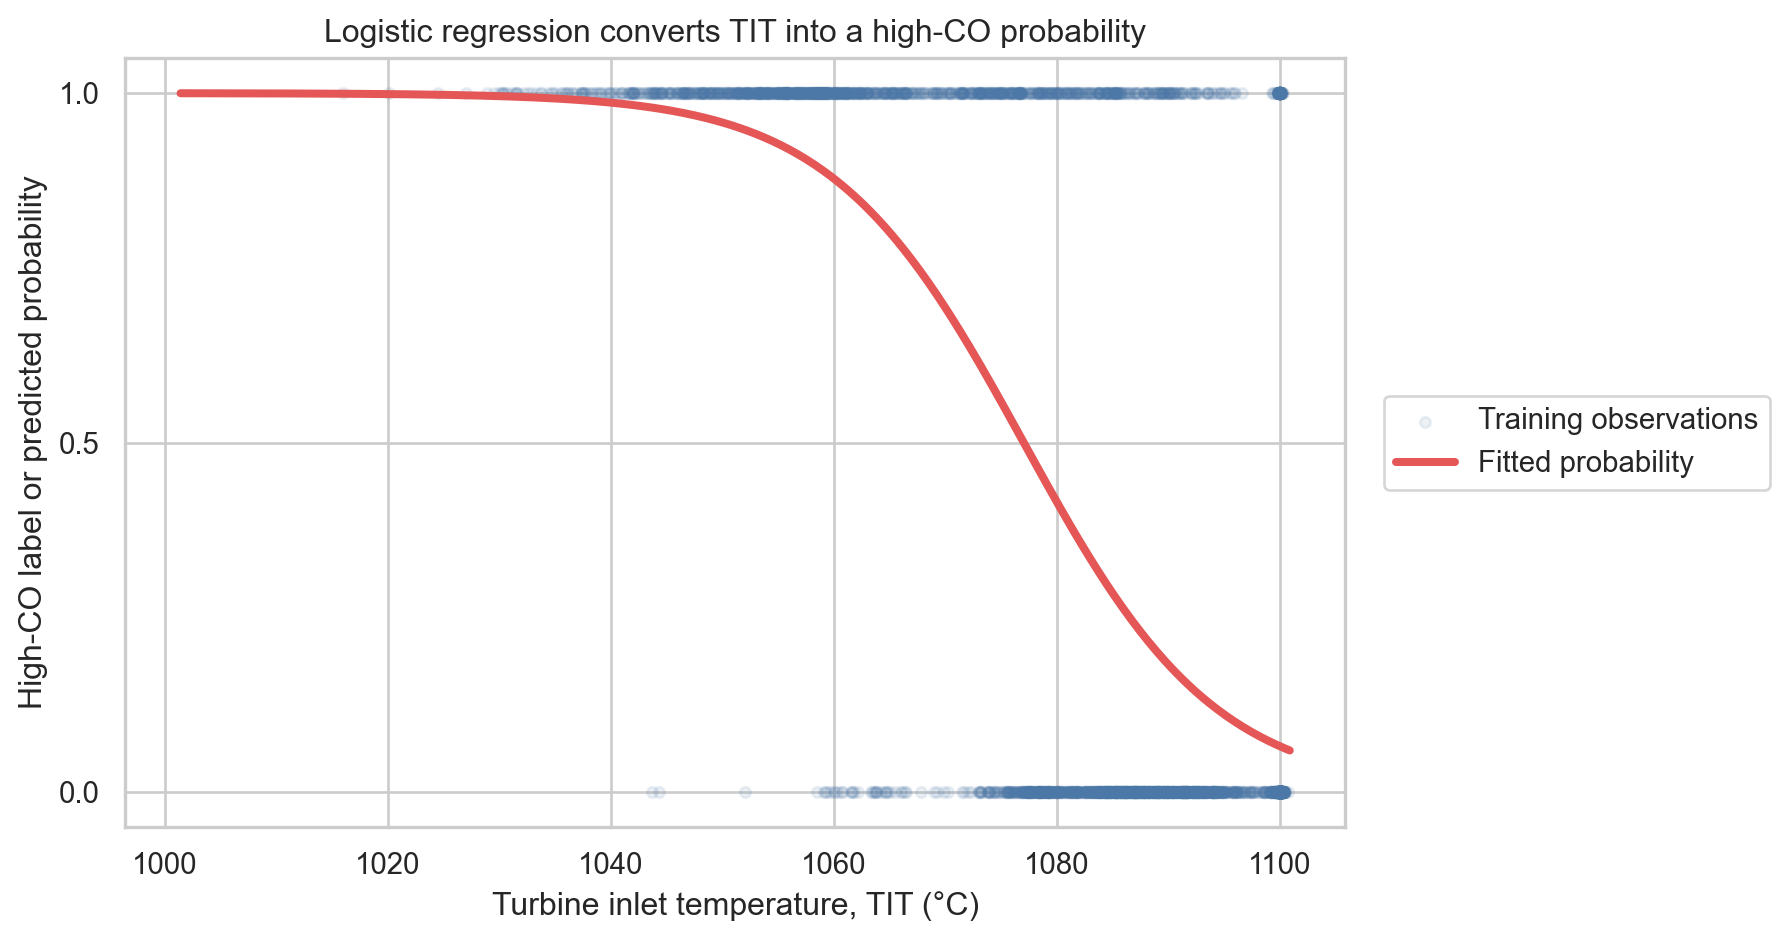

,TIT (°C),Predicted high-CO label
0,1080,0


In [3]:
# Plot a reproducible subset so the observed labels remain readable.
plot_sample = pd.DataFrame({"TIT": X_train["TIT"], "high_co": y_train}).sample(
    n=min(3_000, len(X_train)), random_state=4520
)

# Evaluate the fitted logistic curve across the observed TIT range.
tit_grid = np.linspace(X_train["TIT"].min(), X_train["TIT"].max(), 400)
probability_grid = model.predict_proba(pd.DataFrame({"TIT": tit_grid}))[:, 1]

# Classify one new operating condition with scikit-learn's default decision rule.
example_tit = 1080.0
example_features = pd.DataFrame({"TIT": [example_tit]})
example_prediction = model.predict(example_features)[0]

fig, ax = plt.subplots(figsize=(8.2, 5.2))
ax.scatter(
    plot_sample["TIT"],
    plot_sample["high_co"],
    color="#4C78A8",
    alpha=0.10,
    s=16,
    label="Training observations",
)
ax.plot(tit_grid, probability_grid, color="#E45756", linewidth=3, label="Fitted probability")
ax.set(
    xlabel="Turbine inlet temperature, TIT (°C)",
    ylabel="High-CO label or predicted probability",
    ylim=(-0.05, 1.05),
    yticks=[0, 0.5, 1],
    title="Logistic regression converts TIT into a high-CO probability",
)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.show()

prediction_example = pd.DataFrame(
    {
        "TIT (°C)": [example_tit],
        "Predicted high-CO label": [example_prediction],
    }
)
prediction_example.style.format({"TIT (°C)": "{:.0f}"})


## 3. Read the confusion matrix

A confusion matrix compares the model's alert decision with the measured high-CO label on the test set. Each test observation belongs to exactly one cell:

| | Predicted alert | Predicted no alert |
|---|---:|---:|
| **Observed high CO** | True positive (TP) | False negative (FN) |
| **Observed not high CO** | False positive (FP) | True negative (TN) |

A false negative misses a high-CO condition. A false positive issues an alert when the measured CO value was not high. Which mistake matters more depends on the operating context.

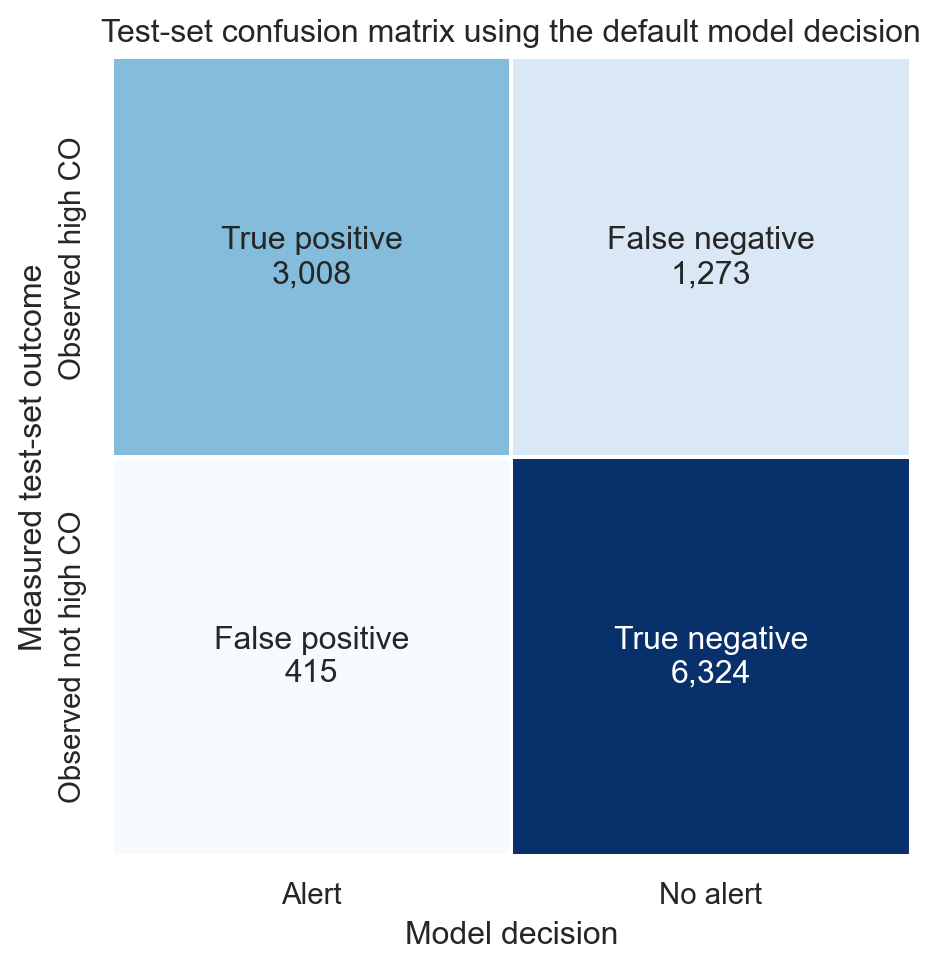

In [4]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, test_predictions, labels=[0, 1]).ravel()

matrix = np.array([[tp, fn], [fp, tn]])
cell_labels = np.array([
    [f"True positive\n{tp:,}", f"False negative\n{fn:,}"],
    [f"False positive\n{fp:,}", f"True negative\n{tn:,}"],
])

fig, ax = plt.subplots(figsize=(7.2, 5.4))
sns.heatmap(
    matrix,
    annot=cell_labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    square=True,
    linewidths=1.5,
    linecolor="white",
    xticklabels=["Alert", "No alert"],
    yticklabels=["Observed high CO", "Observed not high CO"],
    ax=ax,
)
ax.set(
    xlabel="Model decision",
    ylabel="Measured test-set outcome",
    title="Test-set confusion matrix using the default model decision",
)
plt.show()


## 4. Common metrics

From the confusion matrix, we can derive the following commonly used metrics:

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

$$
F_1 = \frac{2\,(\text{Precision})\,(\text{Recall})}
{\text{Precision} + \text{Recall}}
$$

Accuracy asks how often the alert decision is correct overall. Precision asks,
“When the model issues an alert, how often is high CO actually present?” Recall
asks, “Of all high-CO observations, how many did the model alert on?” The
$F_1$ score balances precision and recall through their harmonic mean.

All four metrics depend on the chosen decision threshold.


In [5]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)

metrics = pd.DataFrame(
    {
        "value": [accuracy, precision, recall, f1],
        "plain-language question": [
            "How often is the alert decision correct overall?",
            "When there is an alert, how often is CO actually high?",
            "Of the high-CO observations, how many receive an alert?",
            "How well do precision and recall balance each other?",
        ],
    },
    index=["Accuracy", "Precision", "Recall", "F1 score"],
)
metrics.style.format({"value": "{:.1%}"})


,value,plain-language question
Accuracy,84.7%,How often is the alert decision correct overall?
Precision,87.9%,"When there is an alert, how often is CO actually high?"
Recall,70.3%,"Of the high-CO observations, how many receive an alert?"
F1 score,78.1%,How well do precision and recall balance each other?


## 5. Change the threshold, change the decision

The fitted logistic model has not changed, but the alert policy can. At a
general threshold $\tau$,

$$
\hat{y}_i(\tau) =
\begin{cases}
1, & \hat{p}_i \geq \tau, \\ 
0, & \hat{p}_i < \tau.
\end{cases}
$$

Lowering $\tau$ makes alerts more common. That can increase recall by catching
more high-CO conditions, but it can also increase false positives. Below, we
compare the reference threshold $0.50$ with $0.20$ on the test observations.


In [6]:
def threshold_summary(labels, probabilities, threshold):
    """Return confusion-matrix counts and metrics at one threshold."""
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    return {
        "threshold": threshold,
        "alerts": int(predictions.sum()),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "accuracy": (tp + tn) / len(labels),
        "precision": precision,
        "recall": recall,
        "F1": 2 * precision * recall / (precision + recall),
    }


threshold_comparison = pd.DataFrame(
    [threshold_summary(y_test, test_probabilities, threshold)
     for threshold in [0.50, 0.20]]
).set_index("threshold")
threshold_comparison.style.format(
    {"accuracy": "{:.1%}", "precision": "{:.1%}",
     "recall": "{:.1%}", "F1": "{:.1%}"}
)


,alerts,TN,FP,FN,TP,accuracy,precision,recall,F1
threshold,,,,,,,,,
0.500000,3423,6324,415,1273,3008,84.7%,87.9%,70.3%,78.1%
0.200000,6501,3978,2761,541,3740,70.0%,57.5%,87.4%,69.4%


## 6. Include the cost of mistakes

The appropriate threshold depends on what a false positive and false negative
mean operationally. For one illustrative policy, suppose that missing a
high-CO condition costs three units, while issuing an unnecessary alert costs
one unit. The total decision cost is

$$
C(\tau) = 3\,FN(\tau) + FP(\tau).
$$

This cost ratio is an engineering assumption, not a universal rule. A different
operating context can lead to a different threshold.


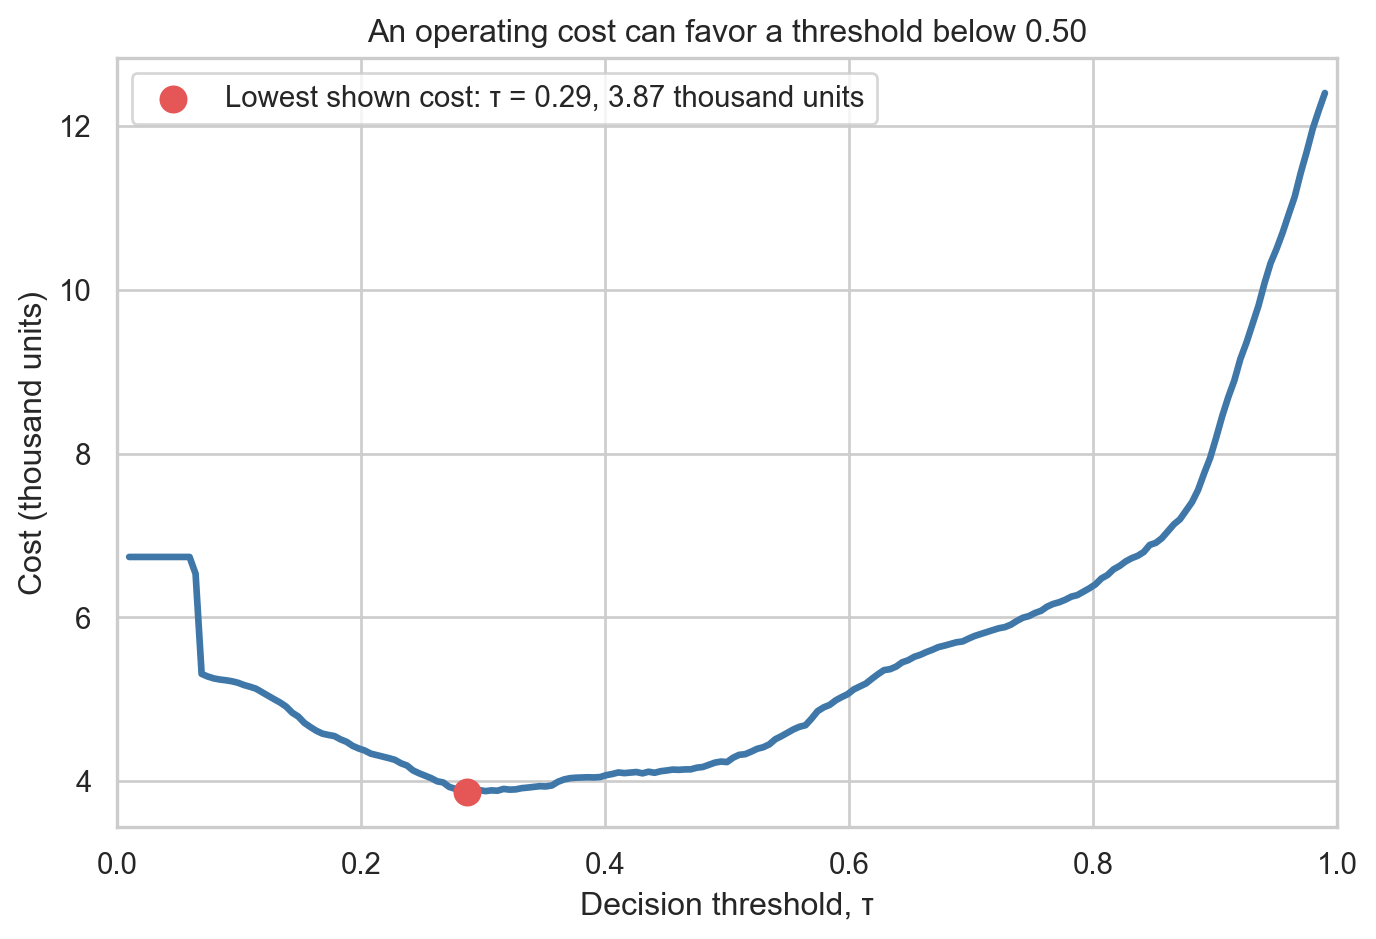

In [7]:
false_negative_cost = 3
false_positive_cost = 1
candidate_thresholds = np.linspace(0.01, 0.99, 199)

cost_by_threshold = pd.DataFrame(
    [threshold_summary(y_test, test_probabilities, threshold)
     for threshold in candidate_thresholds]
)
cost_by_threshold["cost"] = (
    false_negative_cost * cost_by_threshold["FN"]
    + false_positive_cost * cost_by_threshold["FP"]
)
best_cost_row = cost_by_threshold.loc[cost_by_threshold["cost"].idxmin()]

fig, ax = plt.subplots(figsize=(8.2, 5.2))
ax.plot(cost_by_threshold["threshold"], cost_by_threshold["cost"] / 1_000,
        color="#3F78A8", linewidth=2.5)
ax.scatter(best_cost_row["threshold"], best_cost_row["cost"] / 1_000,
           color="#E45756", s=90, zorder=3,
           label=(f"Lowest shown cost: τ = {best_cost_row['threshold']:.2f}, "
                  f"{best_cost_row['cost'] / 1_000:.2f} thousand units"))
ax.set(xlabel="Decision threshold, τ", ylabel="Cost (thousand units)",
       title="An operating cost can favor a threshold below 0.50", xlim=(0, 1))
ax.legend(frameon=True)
plt.show()


## Try it

Change the threshold below and inspect the resulting counts. Then compare them
with the threshold values above.

[← Return to Classification](index.qmd)


In [8]:
# Choose a probability threshold, then inspect the resulting counts.
# my_threshold = 0.35
# my_summary = threshold_summary(y_test, test_probabilities, my_threshold)
# my_summary
